<a href="https://colab.research.google.com/github/alvarosamp/TCC/blob/main/ObsPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Instalando a biblioteca
!pip install obspy


Informações sobre os eixos :

Z = Componente vertical - BHZ
Eixo vertical (baixo e cima)

O que mede ?
- Movimento do solo para cima e para baixo
- Muito sensivel a ondas P ( ondas primárias)
- Geralmente é a componente mais 'forte' em eventos distantes

Componente Norte-sul - BHN
N = Eixo horizonal norte sul
O que mede?
- Movimento horizontal na direção nrote <-> sul
- Importante para calcular dimensão da fonte
- Muito inlfuenciados por onda S

Componente Leste-Oeste BHE:
E = eixo horizonatal Leste <-> Oeste
O que mede?
- Moviemnto horionaltal perpendicular ao Norte e Sul
- Complementa a BHN
- Junto com BHN permite reconstruir o vetor horizontal

Aplicando no contexto do tcc:
VOce provavelmente usa :
PREFERRED_CHANNELS = {"BHZ", "BHN", "BHE"}

Modelos sismicos usam as 3 componetnes
Redes neurais podem usar como input 3 canais (tipo RGB)
Da para calcular a magnitude vetorial :
Magnitude = sqrt(z²+n²+e²)





In [8]:
#Carregando as bibliotecas
import obspy
from obspy import read, UTCDateTime
from obspy.clients.fdsn import Client
from obspy import Trace, Stream
import matplotlib.pyplot as plt
import numpy as np

#Configurando os graficos
plt.style.use('ggplot')
%matplotlib inline

In [9]:
#Criando dados sismicos simulados
#Vamos criar um terremoto para entender
print('Criando a estacao')
#Parametros na nossa estação
taxa_amostragem = 20.0 #20 amostras por segundo
duracao = 30 #Segundos
n_amostras = int(taxa_amostragem * duracao) #Quantidade de amostras

#Vetor de tempo ( 0 a 30 segundos)
tempo = np.arange(n_amostras) / taxa_amostragem

"""
Qual é a diferença de duração e tempo ?
No caso, definimos duração como 30, logo, temos 30 segundos de evento sismico.
Sendo um parametro físico de experimento/simulação

O que é o tempo?
  Nesse exemplo estamos criando o vetor de tempo real, ponto a ponto.
  Ou sjea, Em qual instante cada amostra foi medida

De forma matemática
  taxa_amostragem = 20.0 #20Hz
  duracao = 30 # Segundos
  Logo,: n_amostras = 600, ou seja, teremos 600 pontos

  Agora:
  np.arange(n_amostras)
  gera: [0,1,2,3,4,5,...,599]
  dividindo por 20, temos : [0/20, 1/20],
  ou seja, começa em 0 segundos, termina em aprox 30, passo de 0.05]


  Resumo: Duracao -> Tempo total do sinal -> Escalar
          Tempo -> Vetor com instante de cada amostra -> Vetor

  No meu projeto real:
        Duração = taanho da janela ( ex: 60s no codigo)
        Tempo = Eixo x do gráfico
        taxa amostragem = frequencia do sensor

        Sempre precisamos manter os 3 conectados
        n_amostras = taxa_amostragem * duracao
"""
# Componente Vertical (Z) - onda principal
print("\n📊 Gerando componente vertical (BHZ)...")
sinal_z = (3.0 * np.sin(2 * np.pi * 0.5 * tempo) +   # Onda lenta (0.5 Hz)
           2.0 * np.sin(2 * np.pi * 2.0 * tempo) +   # Onda média (2 Hz)
           1.0 * np.sin(2 * np.pi * 5.0 * tempo) +   # Onda rápida (5 Hz)
           0.8 * np.random.randn(n_amostras))        # Ruído

# Componente Norte-Sul (N)
print("📊 Gerando componente norte-sul (BHN)...")
sinal_n = (2.5 * np.sin(2 * np.pi * 0.5 * tempo + 0.7) +
           1.5 * np.sin(2 * np.pi * 2.0 * tempo - 0.3) +
           0.5 * np.sin(2 * np.pi * 5.0 * tempo + 0.9) +
           0.8 * np.random.randn(n_amostras))

# Componente Leste-Oeste (E)
print("📊 Gerando componente leste-oeste (BHE)...")
sinal_e = (2.2 * np.sin(2 * np.pi * 0.5 * tempo - 0.5) +
           1.8 * np.sin(2 * np.pi * 2.0 * tempo + 0.4) +
           0.7 * np.sin(2 * np.pi * 5.0 * tempo - 0.8) +
           0.8 * np.random.randn(n_amostras))

print(f"\n✅ Dados criados com sucesso!")
print(f"   {n_amostras} amostras por componente")
print(f"   Taxa: {taxa_amostragem} Hz")
print(f"   Duração: {duracao} segundos")

Criando a estacao

📊 Gerando componente vertical (BHZ)...
📊 Gerando componente norte-sul (BHN)...
📊 Gerando componente leste-oeste (BHE)...

✅ Dados criados com sucesso!
   600 amostras por componente
   Taxa: 20.0 Hz
   Duração: 30 segundos


In [10]:
#Entendendo o trace
#trace = um único canal contino
"""
Trace = traço = Um UNICO canal continuo de dados sismicos
- Representa uma componente vertical (ex : vertical, norte ou leste)
- Tem dados igualmente espaços no tempo
- Contém metadados (informaçoes sobre a gravaçao)

"""

#Criando primeiro trace (componente vertical)
trace_z = Trace(data = sinal_z)
#Preenhendo metadados (informaçoes importantes )
trace_z.stats.station = 'Meus' #Nome da estaçao
trace_z.stats.network = 'XX' #Codigo da rede
trace_z.stats.channel = 'BHZ' # B=banda larga, H=alta ganho, Z=vertical
trace_z.stats.sampling_rate = taxa_amostragem
trace_z.stats.starttime = UTCDateTime("2024-01-15T12:00:00")

for chave,valor in trace_z.stats.items():
  print(f'{chave} : {valor}')

sampling_rate : 20.0
delta : 0.05
starttime : 2024-01-15T12:00:00.000000Z
endtime : 2024-01-15T12:00:29.950000Z
npts : 600
calib : 1.0
network : XX
station : Meus
location : 
channel : BHZ


In [11]:
#Explorando o interior de um trac

#Abrindo dentro de um trace
#Um trace tem duas partes principais:
#1.  .data - os numeros (array numpy)
#2.  .stats - os metadados (dicionario)

print("\n📊 PARTE 1: OS DADOS (.data)")
print("-"*40)
print(f"Tipo: {type(trace_z.data)}")
print(f"Formato (shape): {trace_z.data.shape}")
print(f"Número de amostras: {trace_z.stats.npts}")
print(f"\nPrimeiras 20 amostras:")
print(trace_z.data[:20])
print("\nEstatísticas básicas:")
print(f"  Média: {trace_z.data.mean():.3f}")
print(f"  Desvio padrão: {trace_z.data.std():.3f}")
print(f"  Valor mínimo: {trace_z.data.min():.3f}")
print(f"  Valor máximo: {trace_z.data.max():.3f}")

print("\n\n📋 PARTE 2: OS METADADOS (.stats)")
print("-"*40)
print(f"Tipo: {type(trace_z.stats)}")
print(f"\nTodas as informações disponíveis:")
for i, (chave, valor) in enumerate(trace_z.stats.items(), 1):
    print(f"  {i:2d}. {chave:15s} = {valor}")


📊 PARTE 1: OS DADOS (.data)
----------------------------------------
Tipo: <class 'numpy.ndarray'>
Formato (shape): (600,)
Número de amostras: 600

Primeiras 20 amostras:
[-0.4793163   1.48859267  3.79176213  1.85161122  2.32403435  2.41208131
  1.40996304 -0.94164733  1.25632911  3.11792526  2.89041849  3.08762794
  4.40352578  7.00390635  2.85685421  0.60720867  0.88879211  0.64436993
 -0.44586029 -2.33258257]

Estatísticas básicas:
  Média: -0.014
  Desvio padrão: 2.807
  Valor mínimo: -8.063
  Valor máximo: 7.004


📋 PARTE 2: OS METADADOS (.stats)
----------------------------------------
Tipo: <class 'obspy.core.trace.Stats'>

Todas as informações disponíveis:
   1. sampling_rate   = 20.0
   2. delta           = 0.05
   3. starttime       = 2024-01-15T12:00:00.000000Z
   4. endtime         = 2024-01-15T12:00:29.950000Z
   5. npts            = 600
   6. calib           = 1.0
   7. network         = XX
   8. station         = Meus
   9. location        = 
  10. channel         = BHZ

📈 VISUALIZANDO NOSSO PRIMEIRO TRACE

🎨 Plotando com o método .plot() do ObsPy...


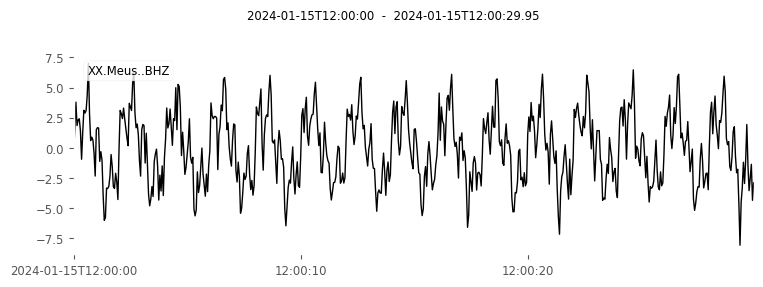


🎨 Plotando com Matplotlib (com zoom)...


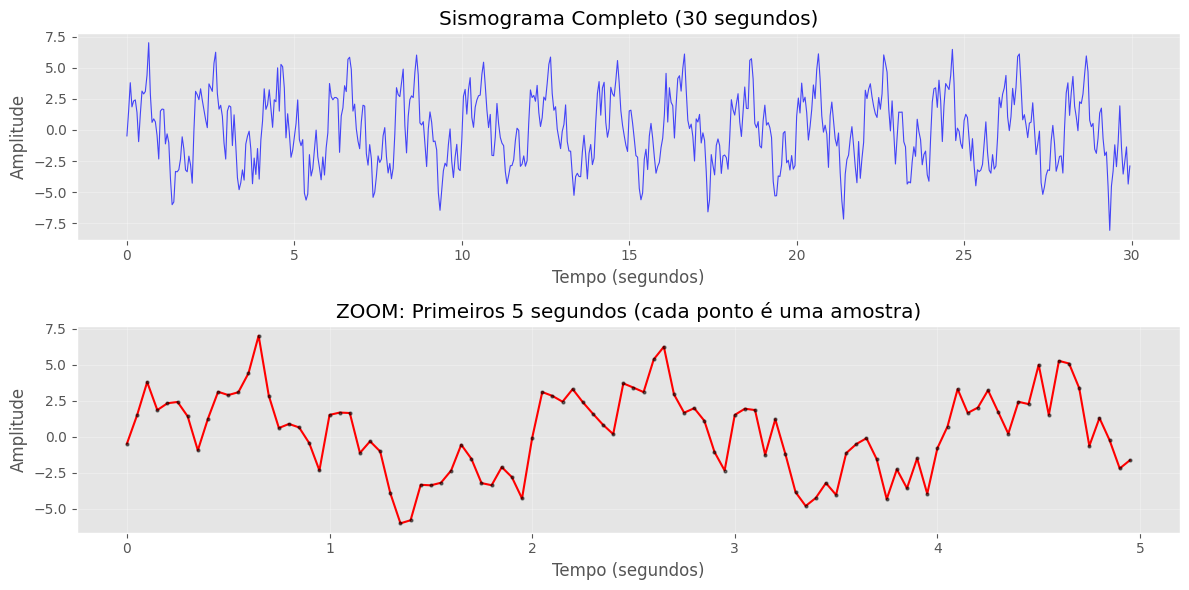


✅ Cada ponto preto é uma amostra!
   Intervalo entre amostras: 50.0 ms


In [12]:
# ============================================
# CÉLULA 6: VISUALIZANDO UM TRACE
# ============================================
# Gráficos para entender nossos dados

print("="*60)
print("📈 VISUALIZANDO NOSSO PRIMEIRO TRACE")
print("="*60)

# Método 1: Plot rápido do ObsPy
print("\n🎨 Plotando com o método .plot() do ObsPy...")
trace_z.plot(size=(800, 300))

# Método 2: Plot com Matplotlib (mais controle)
print("\n🎨 Plotando com Matplotlib (com zoom)...")
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Gráfico 1: Sinal completo
ax = axes[0]
tempo_completo = trace_z.times()
ax.plot(tempo_completo, trace_z.data, 'b-', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Amplitude')
ax.set_title('Sismograma Completo (30 segundos)')
ax.grid(True, alpha=0.3)

# Gráfico 2: Zoom nos primeiros 5 segundos
ax = axes[1]
indices_zoom = tempo_completo < 5
tempo_zoom = tempo_completo[indices_zoom]
dados_zoom = trace_z.data[indices_zoom]

ax.plot(tempo_zoom, dados_zoom, 'r-', linewidth=1.5)
ax.plot(tempo_zoom, dados_zoom, 'ko', markersize=2, alpha=0.5)
ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Amplitude')
ax.set_title('ZOOM: Primeiros 5 segundos (cada ponto é uma amostra)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Cada ponto preto é uma amostra!")
print(f"   Intervalo entre amostras: {1000/taxa_amostragem:.1f} ms")

In [25]:
#Entendendo o stream (multiplos canais)

#Stream = conjunto de traces

'''
Stream = Fluxo = Um conjunto de traces
- Pode ter 1 ou mais canais
- Util para trabalhar com todas componentes juntas
- Permite processamento em lote
'''

#Criando os outros dois traces
trace_n = Trace(data = sinal_n)
trace_e = Trace(data = sinal_e)

#Preenchendo os metadados e ajustando canais
trace_n.stats = trace_z.stats.copy()
trace_e.stats = trace_z.stats.copy()
trace_n.stats.channel = "BHN"# Norte
trace_e.stats.channel = "BHE" #Leste

#Criando um stream com os 3 componentes
nosso_stream = Stream([trace_z, trace_n, trace_e])
print(nosso_stream)
print("="*40)

for i, trace in enumerate(nosso_stream):
    print(f"\nComponente {i+1}: {trace.stats.channel}")
    print(f"  Estação: {trace.stats.station}")
    print(f"  Rede: {trace.stats.network}")
    print(f"  Taxa: {trace.stats.sampling_rate} Hz")
    print(f"  Amostras: {trace.stats.npts}")

3 Trace(s) in Stream:
XX.Meus..BHZ | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHN | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHE | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples

Componente 1: BHZ
  Estação: Meus
  Rede: XX
  Taxa: 20.0 Hz
  Amostras: 600

Componente 2: BHN
  Estação: Meus
  Rede: XX
  Taxa: 20.0 Hz
  Amostras: 600

Componente 3: BHE
  Estação: Meus
  Rede: XX
  Taxa: 20.0 Hz
  Amostras: 600


📊 VISUALIZANDO AS 3 COMPONENTES

🎨 Plot rápido com ObsPy:


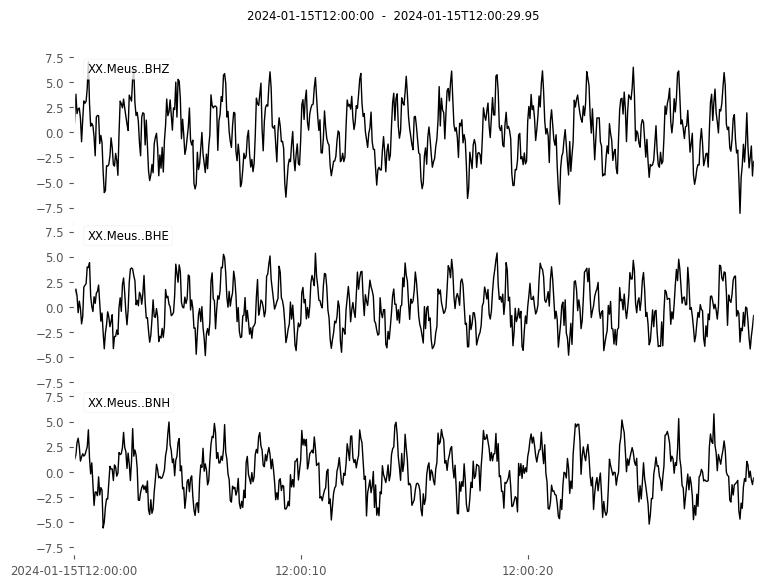


🎨 Plot detalhado com Matplotlib:


KeyError: 'BNH'

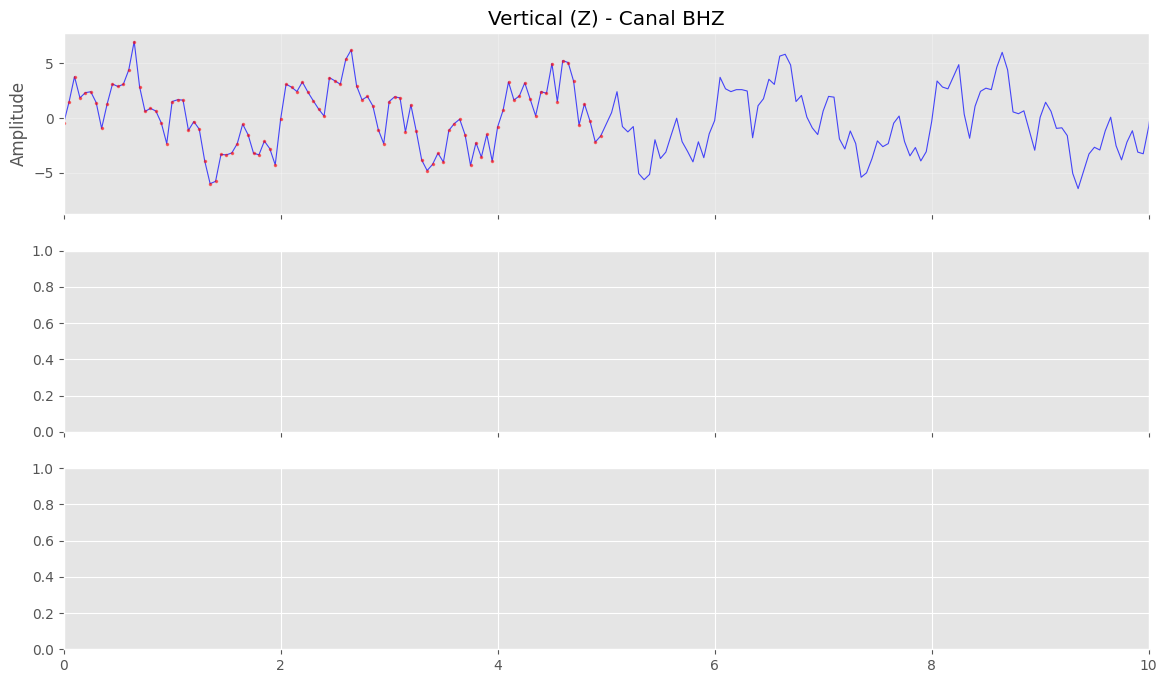

In [14]:
# ============================================
# CÉLULA 8: VISUALIZANDO MÚLTIPLOS CANAIS
# ============================================
# Comparando as 3 componentes

print("="*60)
print("📊 VISUALIZANDO AS 3 COMPONENTES")
print("="*60)

# Plot com ObsPy (simples)
print("\n🎨 Plot rápido com ObsPy:")
nosso_stream.plot(size=(800, 600))

# Plot personalizado com Matplotlib
print("\n🎨 Plot detalhado com Matplotlib:")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Cores para cada componente
cores = {'BHZ': 'blue', 'BHN': 'red', 'BHE': 'green'}
nomes = {'BHZ': 'Vertical (Z)', 'BHN': 'Norte-Sul (N)', 'BHE': 'Leste-Oeste (E)'}

for i, trace in enumerate(nosso_stream):
    tempo = trace.times()
    ax = axes[i]

    # Plot do sinal
    ax.plot(tempo, trace.data, color=cores[trace.stats.channel],
            linewidth=0.8, alpha=0.7)

    # Destacando as primeiras ondas
    ax.plot(tempo[:100], trace.data[:100], 'r.',
            markersize=3, alpha=0.5)

    ax.set_ylabel('Amplitude')
    ax.set_title(f'{nomes[trace.stats.channel]} - Canal {trace.stats.channel}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 10])  # Zoom nos primeiros 10 segundos

axes[-1].set_xlabel('Tempo (segundos)')
plt.suptitle('Sismograma de 3 Componentes - Estação MEUS', fontsize=14)
plt.tight_layout()
plt.show()

🔧 OPERAÇÃO 1: SELECIONANDO CANAIS ESPECÍFICOS

🎯 Selecionando apenas canal BHZ:
1 Trace(s) in Stream:
XX.Meus..BHZ | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples

🎯 Selecionando canais horizontais (N e E):
1 Trace(s) in Stream:
XX.Meus..BHE | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples

🎯 Selecionando estação MEUS:
3 Trace(s) in Stream:
XX.Meus..BHZ | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BNH | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHE | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples


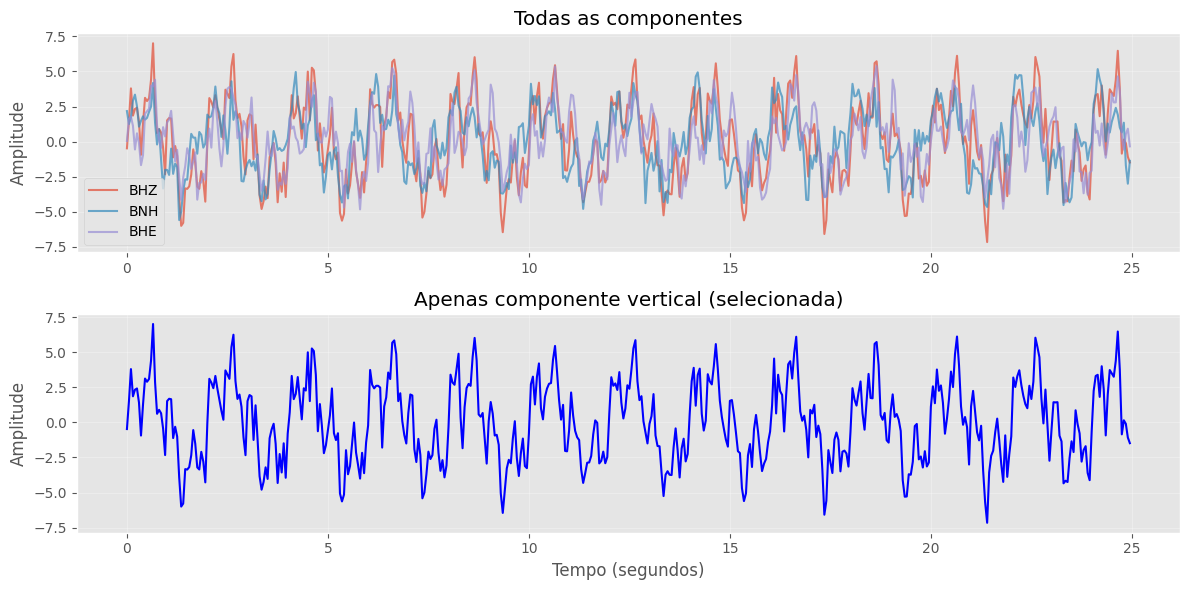

In [15]:
# ============================================
# CÉLULA 9: OPERAÇÕES BÁSICAS - SELEÇÃO DE CANAIS
# ============================================
# Aprendendo a selecionar partes do Stream

print("="*60)
print("🔧 OPERAÇÃO 1: SELECIONANDO CANAIS ESPECÍFICOS")
print("="*60)

# Selecionar apenas a componente vertical
print("\n🎯 Selecionando apenas canal BHZ:")
bhz_only = nosso_stream.select(channel="BHZ")
print(bhz_only)

# Selecionar componentes horizontais
print("\n🎯 Selecionando canais horizontais (N e E):")
horizontal = nosso_stream.select(channel="BHN") + nosso_stream.select(channel="BHE")
print(horizontal)

# Selecionar por estação
print("\n🎯 Selecionando estação MEUS:")
estacao_meus = nosso_stream.select(station="MEUS")
print(estacao_meus)

# Visualizando a seleção
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot 1: Todas componentes
ax = axes[0]
for trace in nosso_stream:
    ax.plot(trace.times()[:500], trace.data[:500],
            label=trace.stats.channel, alpha=0.7)
ax.set_title('Todas as componentes')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Apenas vertical
ax = axes[1]
trace_vertical = bhz_only[0]
ax.plot(trace_vertical.times()[:500], trace_vertical.data[:500],
        'b-', linewidth=1.5)
ax.set_title('Apenas componente vertical (selecionada)')
ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🔧 OPERAÇÃO 2: FILTRAGEM DE SINAIS

🎛️ Aplicando filtro passa-banda (1-4 Hz)...
✅ Filtro aplicado!


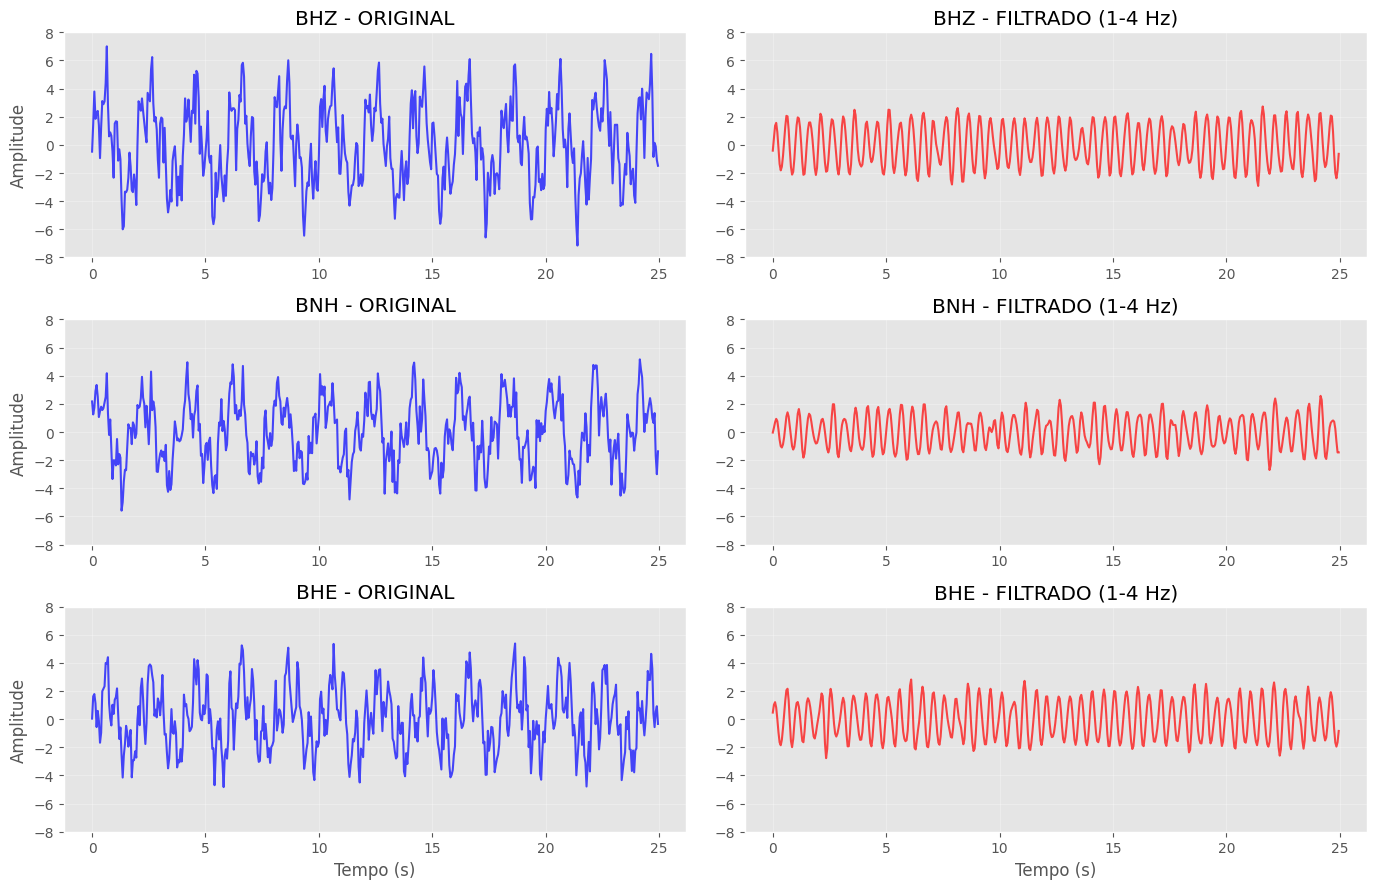


📊 Comparação de frequências:


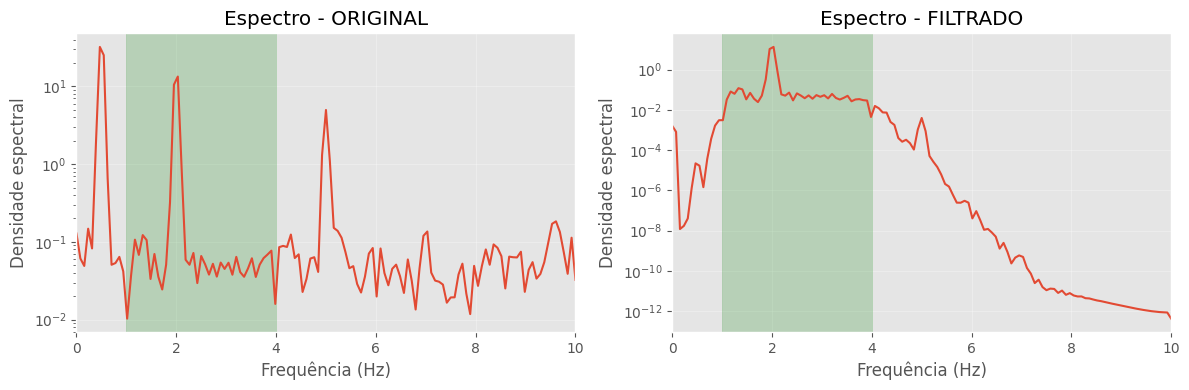

In [16]:
# ============================================
# CÉLULA 10: OPERAÇÕES BÁSICAS - FILTRAGEM
# ============================================
# Aplicando filtros nos dados

print("="*60)
print("🔧 OPERAÇÃO 2: FILTRAGEM DE SINAIS")
print("="*60)

# Fazendo uma cópia para não modificar o original
stream_filtrado = nosso_stream.copy()

print("\n🎛️ Aplicando filtro passa-banda (1-4 Hz)...")
stream_filtrado.filter("bandpass",
                       freqmin=1.0,  # frequência mínima
                       freqmax=4.0,  # frequência máxima
                       corners=4,    # ordem do filtro
                       zerophase=True)  # sem distorção de fase

print("✅ Filtro aplicado!")

# Visualizando o efeito
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for i, (trace_orig, trace_filt) in enumerate(zip(nosso_stream, stream_filtrado)):
    tempo = trace_orig.times()

    # Original (primeira coluna)
    ax = axes[i, 0]
    ax.plot(tempo[:500], trace_orig.data[:500], 'b-', alpha=0.7)
    ax.set_title(f'{trace_orig.stats.channel} - ORIGINAL')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-8, 8])

    # Filtrado (segunda coluna)
    ax = axes[i, 1]
    ax.plot(tempo[:500], trace_filt.data[:500], 'r-', alpha=0.7)
    ax.set_title(f'{trace_filt.stats.channel} - FILTRADO (1-4 Hz)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-8, 8])

axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.tight_layout()
plt.show()

# Comparando espectros
print("\n📊 Comparação de frequências:")

from scipy import signal

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (trace, ax) in enumerate(zip([nosso_stream[0], stream_filtrado[0]], axes)):
    # Calculando espectro
    f, Pxx = signal.welch(trace.data, fs=trace.stats.sampling_rate,
                          nperseg=256)

    ax.semilogy(f, Pxx)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Densidade espectral')
    ax.set_title('Espectro - ' + ('ORIGINAL' if i==0 else 'FILTRADO'))
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 10])
    ax.axvspan(1, 4, alpha=0.2, color='green', label='Filtro passa-banda')

plt.tight_layout()
plt.show()

🔧 OPERAÇÃO 3: DETREND (REMOÇÃO DE TENDÊNCIA)
📈 Dados com tendência linear adicionada!
✅ Detrend linear aplicado!


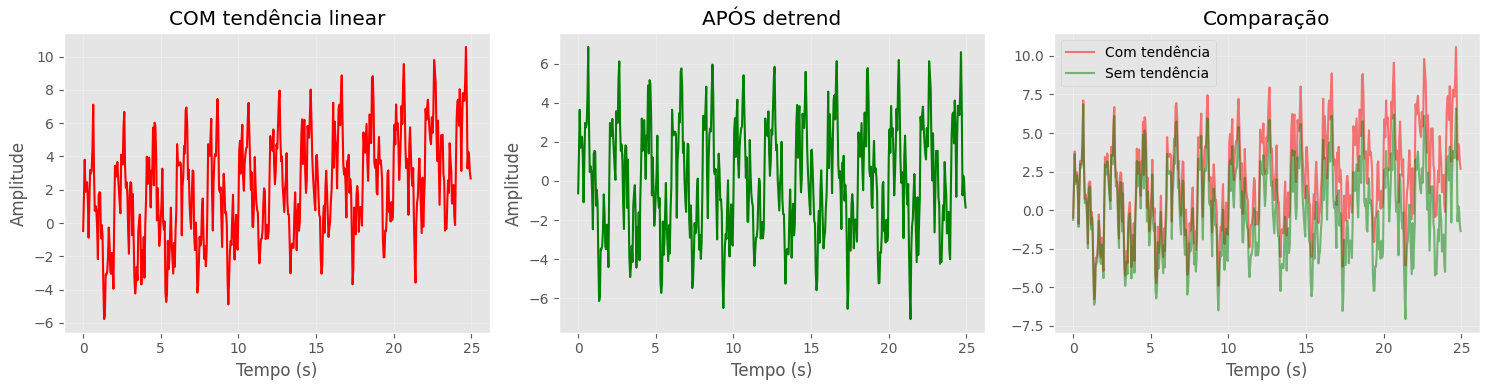


🔧 OPERAÇÃO 4: TAPER (SUAVIZAÇÃO DAS BORDAS)
🎭 Aplicando taper de 10.0% nas bordas...


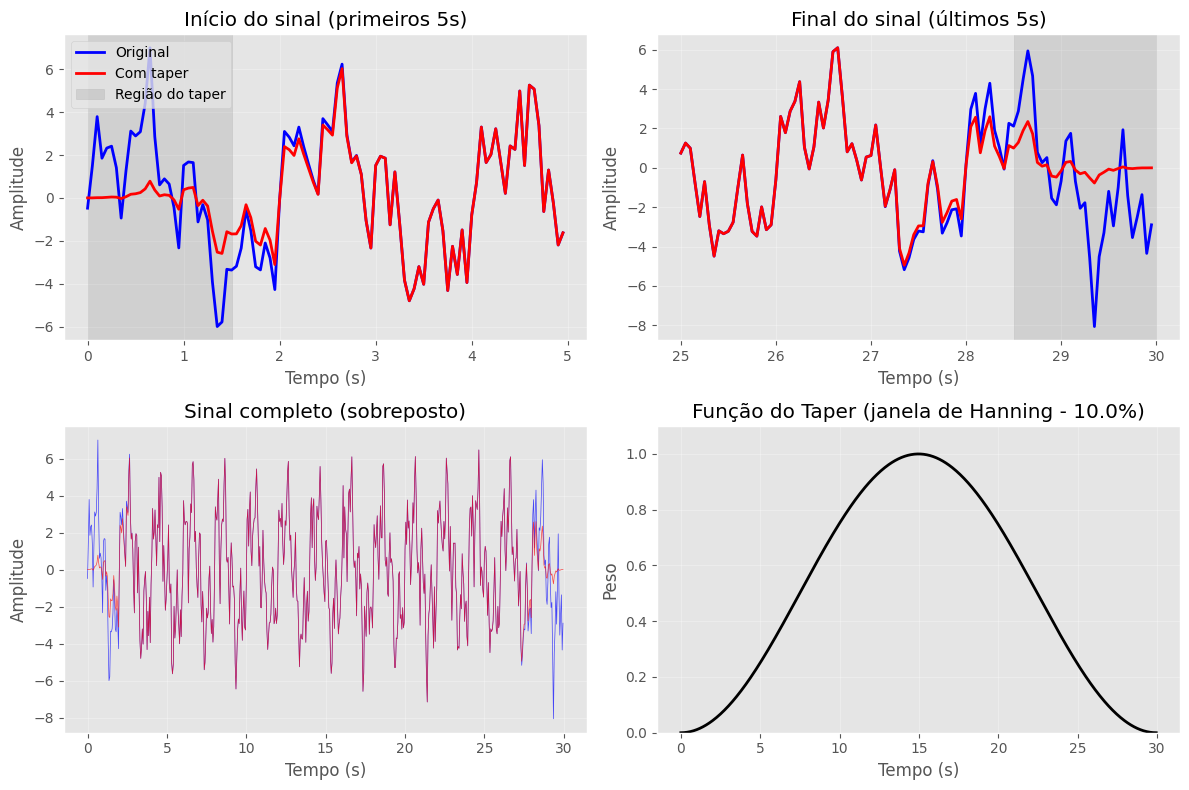

In [17]:
# ============================================
# CÉLULA 11: OPERAÇÕES BÁSICAS - DETREND E TAPER
# ============================================
# Preparando os dados para análise

print("="*60)
print("🔧 OPERAÇÃO 3: DETREND (REMOÇÃO DE TENDÊNCIA)")
print("="*60)

# Criando dados com tendência artificial
stream_com_tendencia = nosso_stream.copy()
for trace in stream_com_tendencia:
    tendencia = np.linspace(0, 5, len(trace.data))
    trace.data = trace.data + tendencia

print("📈 Dados com tendência linear adicionada!")

# Aplicando detrend
stream_sem_tendencia = stream_com_tendencia.copy()
stream_sem_tendencia.detrend("linear")

print("✅ Detrend linear aplicado!")

# Visualizando
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Antes
ax = axes[0]
ax.plot(stream_com_tendencia[0].times()[:500],
        stream_com_tendencia[0].data[:500], 'r-')
ax.set_title('COM tendência linear')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Depois
ax = axes[1]
ax.plot(stream_sem_tendencia[0].times()[:500],
        stream_sem_tendencia[0].data[:500], 'g-')
ax.set_title('APÓS detrend')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Comparação sobreposta
ax = axes[2]
ax.plot(stream_com_tendencia[0].times()[:500],
        stream_com_tendencia[0].data[:500], 'r-', alpha=0.5, label='Com tendência')
ax.plot(stream_sem_tendencia[0].times()[:500],
        stream_sem_tendencia[0].data[:500], 'g-', alpha=0.5, label='Sem tendência')
ax.set_title('Comparação')
ax.set_xlabel('Tempo (s)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🔧 OPERAÇÃO 4: TAPER (SUAVIZAÇÃO DAS BORDAS)")
print("="*60)

# Aplicando taper
stream_com_taper = nosso_stream.copy()
percentual_taper = 0.1  # 10%
stream_com_taper.taper(max_percentage=percentual_taper)

print(f"🎭 Aplicando taper de {percentual_taper*100}% nas bordas...")

# Visualizando o efeito do taper
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Início do sinal
ax = axes[0, 0]
ax.plot(nosso_stream[0].times()[:100], nosso_stream[0].data[:100],
        'b-', label='Original', linewidth=2)
ax.plot(stream_com_taper[0].times()[:100], stream_com_taper[0].data[:100],
        'r-', label='Com taper', linewidth=2)
ax.axvspan(0, 1.5, alpha=0.2, color='gray', label='Região do taper')
ax.set_title('Início do sinal (primeiros 5s)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Fim do sinal
ax = axes[0, 1]
fim_inicio = len(nosso_stream[0].data) - 100
ax.plot(nosso_stream[0].times()[fim_inicio:],
        nosso_stream[0].data[fim_inicio:], 'b-', linewidth=2)
ax.plot(stream_com_taper[0].times()[fim_inicio:],
        stream_com_taper[0].data[fim_inicio:], 'r-', linewidth=2)
ax.axvspan(28.5, 30, alpha=0.2, color='gray')
ax.set_title('Final do sinal (últimos 5s)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Sinal completo
ax = axes[1, 0]
ax.plot(nosso_stream[0].times(), nosso_stream[0].data, 'b-', alpha=0.7, linewidth=0.5)
ax.plot(stream_com_taper[0].times(), stream_com_taper[0].data, 'r-', alpha=0.7, linewidth=0.5)
ax.set_title('Sinal completo (sobreposto)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Função do taper
ax = axes[1, 1]
janela = np.hanning(len(nosso_stream[0].data))
ax.plot(nosso_stream[0].times(), janela, 'k-', linewidth=2)
ax.set_title(f'Função do Taper (janela de Hanning - {percentual_taper*100}%)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Peso')
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# CÉLULA 12: ENTENDENDO O UTCDateTime
# ============================================
# Como trabalhar com tempo em sismologia

print("="*60)
print("⏰ CONCEITO 3: UTCDateTime - TEMPO EM SISMOLOGIA")
print("="*60)
print("""
UTCDateTime = Tempo Universal Coordenado
- Usado para marcar exatamente quando os dados foram gravados
- Permite operações matemáticas com tempo
- Formato ISO: AAAA-MM-DDTHH:MM:SS.sssZ
""")

from obspy import UTCDateTime

# Diferentes formas de criar um tempo
print("\n📅 CRIANDO OBJETOS DE TEMPO:")
print("-"*40)

# Forma 1: String ISO
t1 = UTCDateTime("2024-01-15T12:30:45.123456Z")
print(f"1. De string: {t1}")

# Forma 2: Números separados
t2 = UTCDateTime(2024, 1, 15, 12, 30, 45, 123456)
print(f"2. De números: {t2}")

# Forma 3: Timestamp Unix
t3 = UTCDateTime(1705321845.123456)
print(f"3. De timestamp: {t3}")

# Forma 4: Agora
t4 = UTCDateTime.now()
print(f"4. Agora: {t4}")

print("\n🔍 ACESSANDO COMPONENTES DO TEMPO:")
print("-"*40)
print(f"Ano: {t1.year}")
print(f"Mês: {t1.month}")
print(f"Dia: {t1.day}")
print(f"Hora: {t1.hour}")
print(f"Minuto: {t1.minute}")
print(f"Segundo: {t1.second}")
print(f"Microssegundo: {t1.microsecond}")
print(f"Dia Juliano: {t1.julday}")
print(f"Timestamp Unix: {t1.timestamp}")
print(f"Dia da semana: {t1.weekday}")  # 0=segunda, 6=domingo

print("\n🧮 OPERAÇÕES COM TEMPO:")
print("-"*40)

inicio = UTCDateTime("2024-01-15T12:00:00")
fim = inicio + 3600  # Adiciona 1 hora (3600 segundos)

print(f"Início: {inicio}")
print(f"Fim: {fim}")
print(f"Duração: {fim - inicio} segundos")
print(f"Fim + 30 minutos: {fim + 1800}")

print("\n📊 COMPARAÇÕES:")
print("-"*40)
print(f"inicio < fim? {inicio < fim}")
print(f"inicio == fim? {inicio == fim}")
print(f"inicio > fim? {inicio > fim}")

⏰ CONCEITO 3: UTCDateTime - TEMPO EM SISMOLOGIA

UTCDateTime = Tempo Universal Coordenado
- Usado para marcar exatamente quando os dados foram gravados
- Permite operações matemáticas com tempo
- Formato ISO: AAAA-MM-DDTHH:MM:SS.sssZ


📅 CRIANDO OBJETOS DE TEMPO:
----------------------------------------
1. De string: 2024-01-15T12:30:45.123456Z
2. De números: 2024-01-15T12:30:45.123456Z
3. De timestamp: 2024-01-15T12:30:45.123456Z
4. Agora: 2026-02-24T02:13:25.174972Z

🔍 ACESSANDO COMPONENTES DO TEMPO:
----------------------------------------
Ano: 2024
Mês: 1
Dia: 15
Hora: 12
Minuto: 30
Segundo: 45
Microssegundo: 123456
Dia Juliano: 15
Timestamp Unix: 1705321845.123456
Dia da semana: 0

🧮 OPERAÇÕES COM TEMPO:
----------------------------------------
Início: 2024-01-15T12:00:00.000000Z
Fim: 2024-01-15T13:00:00.000000Z
Duração: 3600.0 segundos
Fim + 30 minutos: 2024-01-15T13:30:00.000000Z

📊 COMPARAÇÕES:
----------------------------------------
inicio < fim? True
inicio == fim? False
ini

⏰ APLICANDO TEMPO REAL AOS DADOS
✅ Início da gravação: 2024-01-15T12:00:00.000000Z

📋 TEMPOS DE CADA TRACE:

Canal BHZ:
  Início: 2024-01-15T12:00:00.000000Z
  Fim: 2024-01-15T12:00:29.950000Z
  Duração: 29.95 s

Canal BNH:
  Início: 2024-01-15T12:00:00.000000Z
  Fim: 2024-01-15T12:00:29.950000Z
  Duração: 29.95 s

Canal BHE:
  Início: 2024-01-15T12:00:00.000000Z
  Fim: 2024-01-15T12:00:29.950000Z
  Duração: 29.95 s

✂️ RECORTANDO DADOS POR TEMPO:
Recorte de 2024-01-15T12:00:05.000000Z até 2024-01-15T12:00:15.000000Z

📦 Stream original: 600 amostras
📦 Stream cortado: 201 amostras


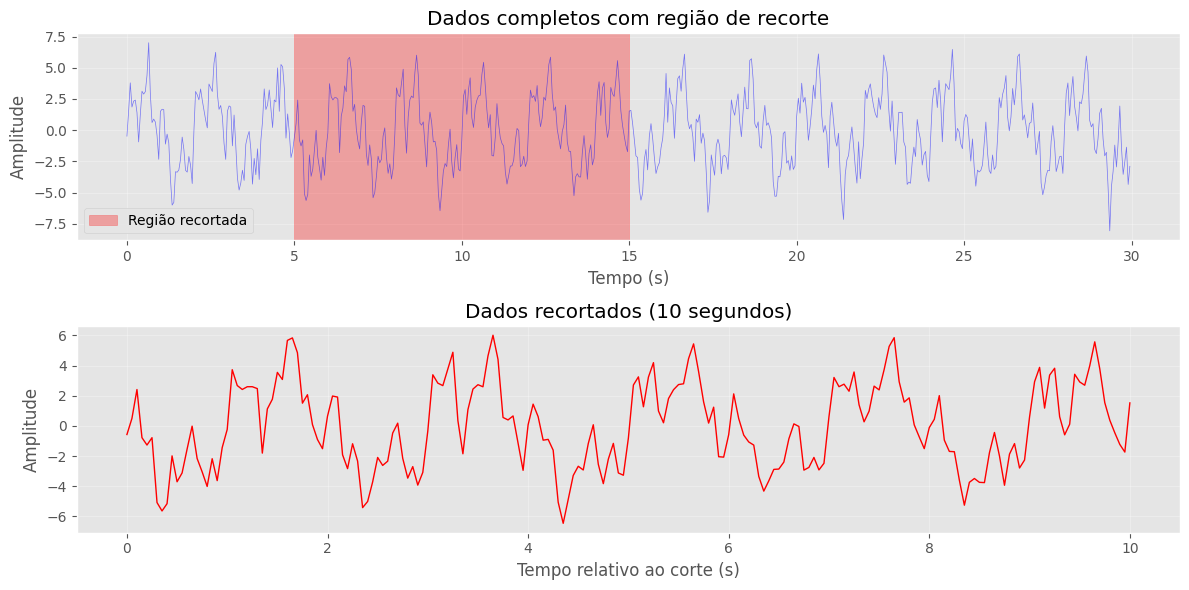

In [21]:
# ============================================
# CÉLULA 13: APLICANDO TEMPO AOS NOSSOS DADOS
# ============================================
# Associando tempos reais aos nossos traces

print("="*60)
print("⏰ APLICANDO TEMPO REAL AOS DADOS")
print("="*60)

# Definindo o início da gravação
inicio_gravacao = UTCDateTime("2024-01-15T12:00:00")

# Atualizando nossos traces com o tempo real
for trace in nosso_stream:
    trace.stats.starttime = inicio_gravacao

print(f"✅ Início da gravação: {inicio_gravacao}")

# Verificando os tempos
print("\n📋 TEMPOS DE CADA TRACE:")
for trace in nosso_stream:
    print(f"\nCanal {trace.stats.channel}:")
    print(f"  Início: {trace.stats.starttime}")
    print(f"  Fim: {trace.stats.endtime}")
    print(f"  Duração: {trace.stats.endtime - trace.stats.starttime} s")

# Criando um slice (recorte) baseado no tempo
print("\n✂️ RECORTANDO DADOS POR TEMPO:")
inicio_corte = inicio_gravacao + 5  # Por exemplo, 5 segundos após o início
fim_corte = inicio_gravacao + 15  # Por exemplo, até 15 segundos (total de 10s de dados)

print(f"Recorte de {inicio_corte} até {fim_corte}")

# Fazendo o slice
stream_cortado = nosso_stream.slice(starttime=inicio_corte,
                                    endtime=fim_corte)

print(f"\n📦 Stream original: {nosso_stream[0].stats.npts} amostras")
# Adicionando uma verificação antes de tentar acessar o elemento
if len(stream_cortado) > 0:
    print(f"📦 Stream cortado: {stream_cortado[0].stats.npts} amostras")
else:
    print("📦 Stream cortado: Vazio (o intervalo de tempo especificado pode estar fora do alcance dos dados)")

# Visualizando o recorte
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Dados completos (destacando região do corte)
ax = axes[0]
tempo_completo = nosso_stream[0].times()
ax.plot(tempo_completo, nosso_stream[0].data, 'b-', alpha=0.5, linewidth=0.5)
ax.axvspan(5, 15, alpha=0.3, color='red', label='Região recortada') # Ajustar a visualização do span
ax.set_title('Dados completos com região de recorte')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Dados recortados
ax = axes[1]
# Verificar novamente se stream_cortado não está vazio antes de plotar
if len(stream_cortado) > 0:
    tempo_cortado = stream_cortado[0].times()  # Tempo relativo ao início do corte
    ax.plot(tempo_cortado, stream_cortado[0].data, 'r-', linewidth=1)
    ax.set_title('Dados recortados (10 segundos)') # Ajustar o título
    ax.set_xlabel('Tempo relativo ao corte (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "Nenhum dado para plotar no recorte", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title('Dados recortados (Vazio)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# CÉLULA 14: ENTENDENDO O CLIENT (DOWNLOAD DE DADOS REAIS)
# ============================================
# Como baixar dados de centros de pesquisa

print("="*60)
print("📡 CONCEITO 4: CLIENT - DOWNLOAD DE DADOS REAIS")
print("="*60)
print("""
Client = Cliente que conecta a bancos de dados sismológicos
- IRIS (EUA) - um dos maiores do mundo
- AUSPASS (Austrália)
- RSBR (Brasil)
- E muitos outros...
""")

from obspy.clients.fdsn import Client

# Criando clientes para diferentes centros
print("\n🌐 CRIANDO CLIENTES:")
iris = Client("IRIS")
auspass = Client("AUSPASS")
# rsbr = Client("RSBR") # Comentado devido a "ValueError: The FDSN service shortcut `RSBR` is unknown."

print("✅ Cliente IRIS criado")
print("✅ Cliente AUSPASS criado")
# print("✅ Cliente RSBR criado") # Comentado devido a "ValueError: The FDSN service shortcut `RSBR` is unknown."

# Buscando informações sobre estações disponíveis
print("\n🔍 BUSCANDO ESTAÇÕES DA REDE IU:")
try:
    # Busca estações da rede IU (International)
    inventario = iris.get_stations(network="IU",
                                   channel="BHZ",
                                   starttime=UTCDateTime("2024-01-15"),
                                   endtime=UTCDateTime("2024-01-16"))

    print("📋 Estações encontradas:")
    print(inventario)

except Exception as e:
    print(f"⚠️ Não foi possível buscar dados: {e}")
    print("(Isso é normal se estiver sem internet ou servidor ocupado)")

📡 CONCEITO 4: CLIENT - DOWNLOAD DE DADOS REAIS

Client = Cliente que conecta a bancos de dados sismológicos
- IRIS (EUA) - um dos maiores do mundo
- AUSPASS (Austrália)
- RSBR (Brasil)
- E muitos outros...


🌐 CRIANDO CLIENTES:
✅ Cliente IRIS criado
✅ Cliente AUSPASS criado

🔍 BUSCANDO ESTAÇÕES DA REDE IU:
📋 Estações encontradas:
Inventory created at 2026-02-24T02:15:19.577500Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2024-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			IU
		Stations (76):
			IU.ADK (Adak, Aleutian Islands, Alaska)
			IU.AFI (Afiamalu, Samoa)
			IU.ANMO (Albuquerque, New Mexico, USA)
			IU.ANTO (Ankara, Turkey)
			IU.BBSR (Bermuda Institute of Ocean Sciences, St George's Bermuda)
			IU.BILL (Bilibino, Russia)
			IU.CASY (Casey, Antarctica)
			IU.CCM (Cathedral Cave, Missouri, USA)
			IU.CHTO (Chiang Mai, Thailand)
			IU.COLA (College Outpost, Alaska, USA

🎯 EXEMPLO COMPLETO: PIPELINE DE PROCESSAMENTO

📋 ETAPA 1: DEFININDO PARÂMETROS
----------------------------------------
Usando dados simulados da estação MEUS
Período: 2024-01-15T12:00:00.000000Z até 2024-01-15T12:00:29.950000Z

🔧 ETAPA 2: PRÉ-PROCESSAMENTO
----------------------------------------
✅ Detrend aplicado
✅ Taper de 5% aplicado
✅ Filtro passa-banda 0.5-3.0 Hz aplicado

📊 ETAPA 3: EXTRAINDO INFORMAÇÕES
----------------------------------------

📈 Canal BHZ:
  Amplitude RMS: 2.032
  Amplitude máxima: 5.116
  Energia total: 2477.927

📈 Canal BNH:
  Amplitude RMS: 1.652
  Amplitude máxima: 4.038
  Energia total: 1637.378

📈 Canal BHE:
  Amplitude RMS: 1.660
  Amplitude máxima: 3.954
  Energia total: 1652.436

🎨 ETAPA 4: VISUALIZAÇÃO FINAL
----------------------------------------


KeyError: 'BNH'

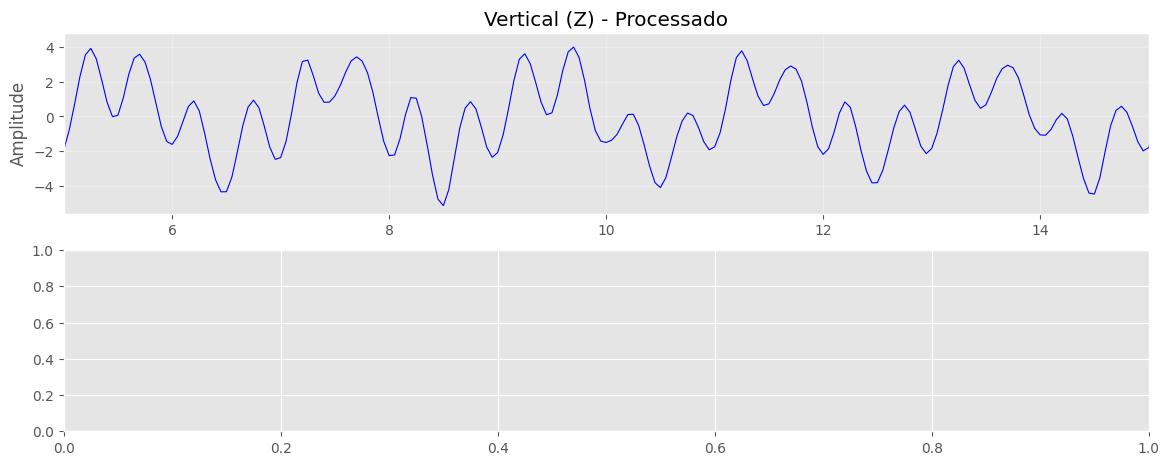

In [24]:
# ============================================
# CÉLULA 15: EXEMPLO COMPLETO - PIPELINE BÁSICO
# ============================================
# Juntando tudo que aprendemos

print("="*60)
print("🎯 EXEMPLO COMPLETO: PIPELINE DE PROCESSAMENTO")
print("="*60)

"""
Este é um fluxo de trabalho típico em sismologia:
1. Definir período de interesse
2. Baixar dados (ou usar dados simulados)
3. Pré-processar (detrend, taper)
4. Filtrar
5. Visualizar
6. Extrair informações
"""

print("\n📋 ETAPA 1: DEFININDO PARÂMETROS")
print("-"*40)

# Usando nossos dados simulados (já que estamos offline)
dados_trabalho = nosso_stream.copy()
print(f"Usando dados simulados da estação MEUS")
print(f"Período: {dados_trabalho[0].stats.starttime} até "
      f"{dados_trabalho[0].stats.endtime}")

print("\n🔧 ETAPA 2: PRÉ-PROCESSAMENTO")
print("-"*40)

# Remover tendência
dados_trabalho.detrend("linear")
print("✅ Detrend aplicado")

# Aplicar taper
dados_trabalho.taper(max_percentage=0.05)
print("✅ Taper de 5% aplicado")

# Filtrar
dados_trabalho.filter("bandpass", freqmin=0.5, freqmax=3.0)
print("✅ Filtro passa-banda 0.5-3.0 Hz aplicado")

print("\n📊 ETAPA 3: EXTRAINDO INFORMAÇÕES")
print("-"*40)

# Calculando estatísticas para cada canal
for trace in dados_trabalho:
    print(f"\n📈 Canal {trace.stats.channel}:")
    print(f"  Amplitude RMS: {np.sqrt(np.mean(trace.data**2)):.3f}")
    print(f"  Amplitude máxima: {np.max(np.abs(trace.data)):.3f}")
    print(f"  Energia total: {np.sum(trace.data**2):.3f}")

print("\n🎨 ETAPA 4: VISUALIZAÇÃO FINAL")
print("-"*40)

fig = plt.figure(figsize=(14, 8))

# Plot dos 3 canais processados
for i, trace in enumerate(dados_trabalho):
    plt.subplot(3, 1, i+1)
    tempo = trace.times()
    plt.plot(tempo, trace.data, color=cores[trace.stats.channel],
            linewidth=0.8)
    plt.ylabel('Amplitude')
    plt.title(f'{nomes[trace.stats.channel]} - Processado')
    plt.grid(True, alpha=0.3)
    plt.xlim([5, 15])  # Zoom em 10 segundos

plt.xlabel('Tempo (segundos)')
plt.suptitle('Dados Processados - Pipeline Completo', fontsize=14)
plt.tight_layout()
plt.show()